# 🔧 02 — Prepare SAR + Optical Scenes
### Amazon Deforestation — Multi-Sensor Change Detection

Loads, calibrates, and fuses Sentinel-1 SAR and Sentinel-2 optical data
into a unified multi-sensor representation for DOFA inference.

**SAR preprocessing steps applied:**
1. Convert dB to linear scale
2. Speckle filtering (Lee filter 5x5)
3. Compute SAR indices (VH/VV ratio, RVI)
4. Normalise to 0-1

**Fusion strategy:**
- Stack SAR and optical bands into a 5-channel array: [R, G, B, VV_norm, VH_norm]
- Pass optical (R,G,B) to DOFA with Sentinel-2 wavelengths
- Pass SAR (VV, VH) to DOFA with SAR-equivalent wavelengths
- Compare segmentation maps from both sensors
- Fuse predictions by confidence voting


## ⚙️ Configuration

In [1]:
import numpy as np
import rasterio
from pathlib import Path
from scipy.ndimage import uniform_filter
import warnings
warnings.filterwarnings("ignore")

RAW_DIR      = Path("data/raw_sar_optical")
PREPARED_DIR = Path("data/prepared_sar_optical")
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration set")
for year in ["2019", "2024"]:
    sar_vv = RAW_DIR / "sar" / year / f"S1_VV_{year}.tif"
    s2_b04 = RAW_DIR / "optical" / year / f"S2_B04_{year}.tif"
    print(f"  {year}: SAR={'ok' if sar_vv.exists() else 'missing'}  Optical={'ok' if s2_b04.exists() else 'missing'}")


Configuration set
  2019: SAR=ok  Optical=ok
  2024: SAR=ok  Optical=ok


## 📡 Step 1 — SAR Preprocessing

In [2]:
def lee_filter(img, size=5):
    """Lee speckle filter for SAR imagery."""
    img_mean = uniform_filter(img, size)
    img_sq   = uniform_filter(img**2, size)
    img_var  = img_sq - img_mean**2
    overall_var = np.var(img)
    weight   = img_var / (img_var + overall_var + 1e-10)
    return img_mean + weight * (img - img_mean)

def preprocess_sar(year):
    """Load SAR bands, apply Lee filter, compute indices, normalise."""
    sar_dir = RAW_DIR / "sar" / year

    with rasterio.open(sar_dir / f"S1_VV_{year}.tif") as src:
        vv_db   = src.read(1).astype(np.float32)
        profile = src.profile

    with rasterio.open(sar_dir / f"S1_VH_{year}.tif") as src:
        vh_db = src.read(1).astype(np.float32)

    # Convert dB to linear scale
    vv_lin = 10 ** (vv_db / 10.0)
    vh_lin = 10 ** (vh_db / 10.0)

    # Apply Lee speckle filter
    vv_filt = lee_filter(vv_lin)
    vh_filt = lee_filter(vh_lin)

    # Convert back to dB after filtering
    vv_filt_db = 10 * np.log10(vv_filt + 1e-10)
    vh_filt_db = 10 * np.log10(vh_filt + 1e-10)

    # SAR indices
    # VH/VV ratio — high = forest (volume scattering), low = bare soil
    vh_vv_ratio = vh_filt_db - vv_filt_db   # dB difference = ratio in linear

    # Radar Vegetation Index (RVI) — sensitive to vegetation density
    rvi = (4 * vh_filt) / (vv_filt + vh_filt + 1e-10)

    # Normalise all bands to 0-1 using percentile stretching
    def norm(x):
        p2, p98 = np.percentile(x, 2), np.percentile(x, 98)
        return np.clip((x - p2) / (p98 - p2 + 1e-6), 0, 1)

    sar_stack = np.stack([
        norm(vv_filt_db),    # channel 0: VV (dB, filtered)
        norm(vh_filt_db),    # channel 1: VH (dB, filtered)
        norm(vh_vv_ratio),   # channel 2: VH/VV ratio
        norm(rvi),           # channel 3: RVI
    ], axis=0)

    # Save
    out_path = PREPARED_DIR / f"sar_{year}.tif"
    p = profile.copy()
    p.update(count=4, dtype="float32", driver="GTiff", compress="lzw")
    with rasterio.open(out_path, "w", **p) as dst:
        dst.write(sar_stack.astype(np.float32))

    print(f"   SAR {year}: VV mean={vv_filt_db.mean():.2f} dB  RVI mean={rvi.mean():.3f}")
    return sar_stack, profile

print("Preprocessing SAR scenes...")
sar_2019, sar_profile = preprocess_sar("2019")
sar_2024, _           = preprocess_sar("2024")
print("Done")


Preprocessing SAR scenes...
   SAR 2019: VV mean=-7.81 dB  RVI mean=0.840
   SAR 2024: VV mean=-7.29 dB  RVI mean=0.650
Done


## 🌿 Step 2 — Optical Preprocessing

In [3]:
def preprocess_optical(year):
    """Load Sentinel-2 bands, normalise, compute NDVI."""
    opt_dir = RAW_DIR / "optical" / year

    def load_band(name):
        with rasterio.open(opt_dir / f"S2_{name}_{year}.tif") as src:
            return src.read(1).astype(np.float32), src.profile

    b04, profile = load_band("B04")   # Red
    b03, _       = load_band("B03")   # Green
    b02, _       = load_band("B02")   # Blue
    b08, _       = load_band("B08")   # NIR

    # Normalise to 0-1
    def norm(x):
        p2, p98 = np.percentile(x, 2), np.percentile(x, 98)
        return np.clip((x - p2) / (p98 - p2 + 1e-6), 0, 1)

    rgb  = np.stack([norm(b04), norm(b03), norm(b02)], axis=0)
    ndvi = np.clip((b08 - b04) / (b08 + b04 + 1e-6), -1, 1)

    # Save RGB
    out_path = PREPARED_DIR / f"optical_{year}.tif"
    p = profile.copy()
    p.update(count=3, dtype="float32", driver="GTiff", compress="lzw")
    with rasterio.open(out_path, "w", **p) as dst:
        dst.write(rgb.astype(np.float32))

    # Save NDVI
    ndvi_path = PREPARED_DIR / f"ndvi_{year}.tif"
    p2 = profile.copy()
    p2.update(count=1, dtype="float32", driver="GTiff", compress="lzw")
    with rasterio.open(ndvi_path, "w", **p2) as dst:
        dst.write(ndvi[np.newaxis, :].astype(np.float32))

    print(f"   Optical {year}: NDVI mean={ndvi.mean():.3f}  RGB shape={rgb.shape}")
    return rgb, ndvi, profile

print("Preprocessing optical scenes...")
opt_2019, ndvi_2019, opt_profile = preprocess_optical("2019")
opt_2024, ndvi_2024, _           = preprocess_optical("2024")
print("Done")


Preprocessing optical scenes...
   Optical 2019: NDVI mean=0.707  RGB shape=(3, 512, 512)
   Optical 2024: NDVI mean=0.181  RGB shape=(3, 512, 512)
Done


## 🔀 Step 3 — Fuse SAR + Optical

In [4]:
def fuse_sar_optical(sar, optical, year):
    """
    Stack SAR and optical bands into a unified 5-channel representation.

    Channels:
      0: R  (optical, 0.665 um)
      1: G  (optical, 0.549 um)
      2: B  (optical, 0.481 um)
      3: VV (SAR C-band ~5.6 cm ~ 0.056 m → mapped to 0.056 um for DOFA)
      4: VH (SAR C-band)
    """
    # Align shapes
    H = min(sar.shape[1], optical.shape[1])
    W = min(sar.shape[2], optical.shape[2])
    sar     = sar[:, :H, :W]
    optical = optical[:, :H, :W]

    # Fused stack: RGB + VV + VH
    fused = np.concatenate([
        optical[:3],    # R, G, B
        sar[:2],        # VV, VH
    ], axis=0)          # shape: (5, H, W)

    # Save
    out_path = PREPARED_DIR / f"fused_{year}.tif"
    profile  = sar_profile.copy()
    profile.update(count=5, dtype="float32", driver="GTiff", compress="lzw",
                   height=H, width=W)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(fused.astype(np.float32))

    print(f"   Fused {year}: shape={fused.shape}  path={out_path}")
    return fused

print("Fusing SAR + Optical...")
fused_2019 = fuse_sar_optical(sar_2019, opt_2019, "2019")
fused_2024 = fuse_sar_optical(sar_2024, opt_2024, "2024")
print("Done. Proceed to: 03_fusion_change_detection.ipynb")


Fusing SAR + Optical...
   Fused 2019: shape=(5, 512, 512)  path=data\prepared_sar_optical\fused_2019.tif
   Fused 2024: shape=(5, 512, 512)  path=data\prepared_sar_optical\fused_2024.tif
Done. Proceed to: 03_fusion_change_detection.ipynb


## 🖼️ Step 4 — Preview All Layers

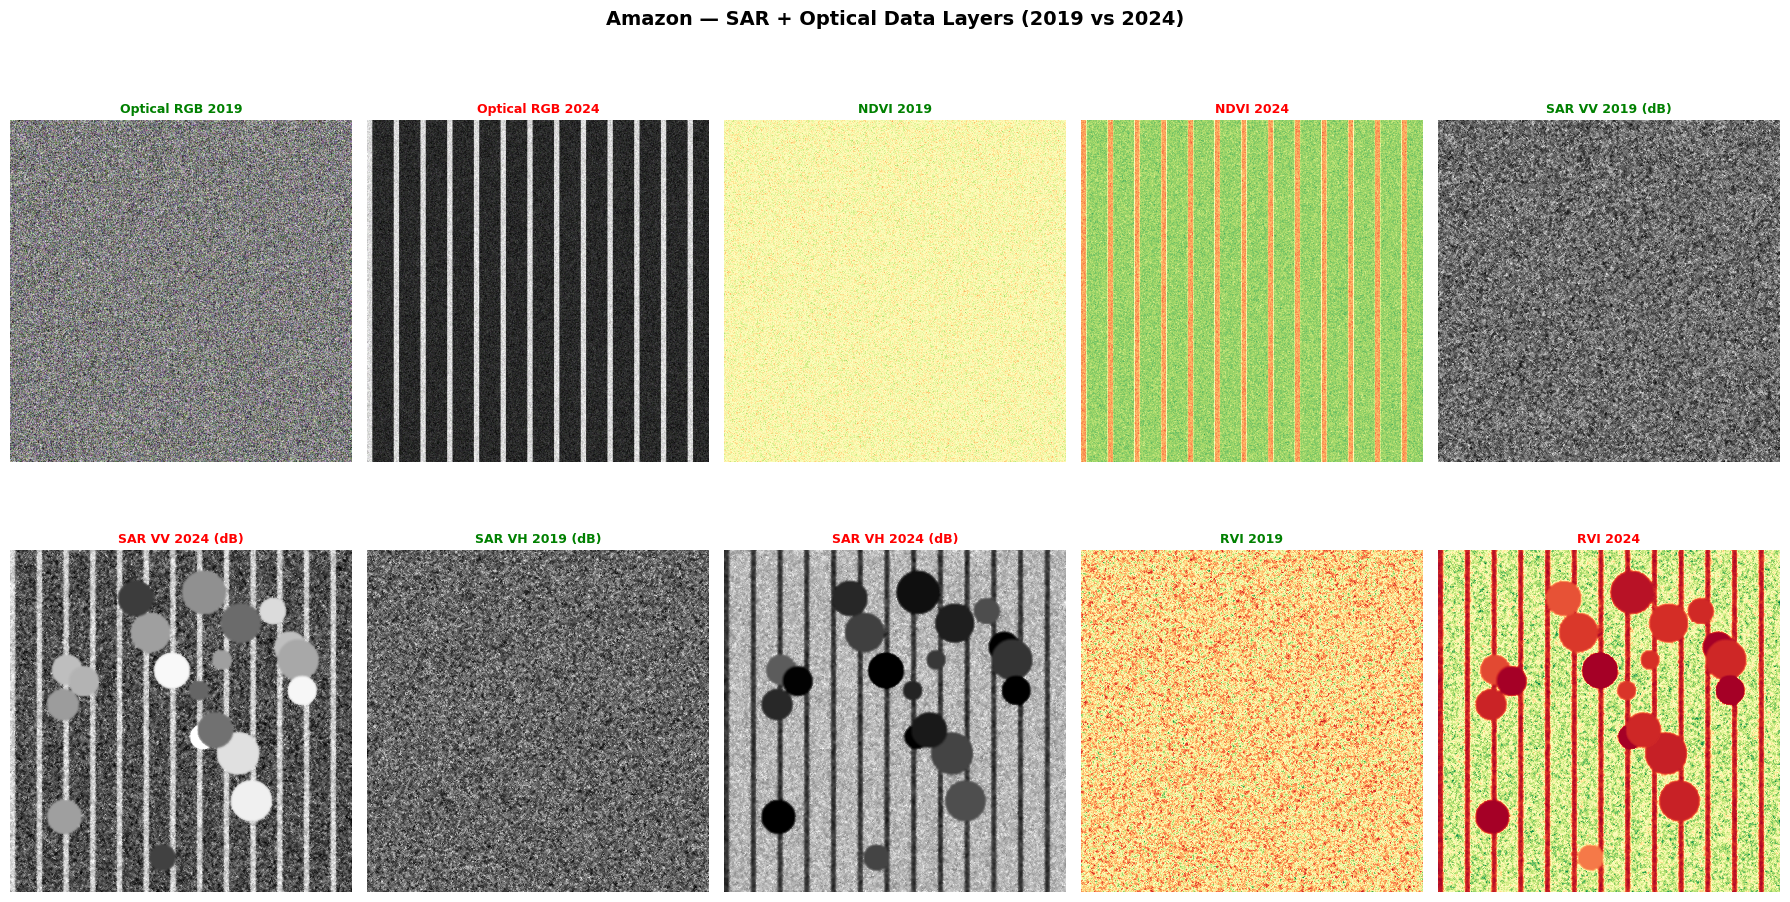

Preview saved


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Amazon — SAR + Optical Data Layers (2019 vs 2024)", fontsize=14, fontweight="bold")

layers = [
    (opt_2019.transpose(1,2,0).clip(0,1), "Optical RGB 2019",  "green"),
    (opt_2024.transpose(1,2,0).clip(0,1), "Optical RGB 2024",  "red"),
    (ndvi_2019,                            "NDVI 2019",         "green"),
    (ndvi_2024,                            "NDVI 2024",         "red"),
    (sar_2019[0],                          "SAR VV 2019 (dB)",  "green"),
    (sar_2024[0],                          "SAR VV 2024 (dB)",  "red"),
    (sar_2019[1],                          "SAR VH 2019 (dB)",  "green"),
    (sar_2024[1],                          "SAR VH 2024 (dB)",  "red"),
    (sar_2019[3],                          "RVI 2019",          "green"),
    (sar_2024[3],                          "RVI 2024",          "red"),
]

for i, (data, title, col) in enumerate(layers):
    ax = fig.add_subplot(2, 5, i+1)
    if data.ndim == 3:
        ax.imshow(data)
    else:
        cmap = "RdYlGn" if "NDVI" in title or "RVI" in title else "gray"
        ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=9, fontweight="bold", color=col)
    ax.axis("off")

plt.tight_layout()
plt.savefig(PREPARED_DIR / "preview_all_layers.png", dpi=120, bbox_inches="tight")
plt.show()
print("Preview saved")
